<a href="https://colab.research.google.com/github/mrunalsamrutwar/Smart-Irrigation-Prediction-Soil_ML-/blob/main/ML_TAE_KNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN Model

Aim: To build and evaluate a K-Nearest Neighbors (KNN) model for irrigation prediction and study the effect of number of neighbors.

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path="/content/drive/MyDrive/ML_Dataset/smart_irrigation_dataset1.csv"
df=pd.read_csv(path)
df.head(5)

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation
0,32.57,74.89,39.76,8.73,0
1,39.66,20.05,62.95,2.63,0
2,27.28,80.13,16.00,0.32,1
3,34.55,52.32,45.56,14.21,0
4,24.92,50.13,26.45,8.21,0


In [5]:
df.describe()

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,27.561700,60.191187,42.398653,10.141427,0.078000
std,7.237384,22.977413,21.429685,5.836865,0.268261
min,15.010000,20.050000,5.020000,0.010000,0.000000
25%,21.547500,40.452500,24.170000,5.047500,0.000000
50%,27.395000,60.695000,41.845000,10.230000,0.000000
75%,33.992500,79.645000,60.922500,15.315000,0.000000
max,39.980000,99.930000,79.980000,19.990000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    1500 non-null   float64
 1   Humidity       1500 non-null   float64
 2   Soil_Moisture  1500 non-null   float64
 3   Rainfall       1500 non-null   float64
 4   Irrigation     1500 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.7 KB


In [7]:
df.shape

(1500, 5)

In [8]:
df.columns

Index(['Temperature', 'Humidity', 'Soil_Moisture', 'Rainfall', 'Irrigation'], dtype='object')

In [9]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Soil_Moisture,0
Rainfall,0
Irrigation,0


In [10]:
df.isnull().any().any()

np.False_

In [11]:
df[df.isnull().any(axis = 1)]

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation


In [12]:
df.columns

Index(['Temperature', 'Humidity', 'Soil_Moisture', 'Rainfall', 'Irrigation'], dtype='object')

In [13]:
before_rows=df.shape[0]
df=df.dropna()
after_rows=df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("The no. of dropped rows are:", before_rows - after_rows)

Before rows: 1500
After rows: 1500
The no. of dropped rows are: 0


In [14]:
clean_data = df.copy()
clean_data['high_humidity_label'] = (clean_data['Humidity'] > 24.99)*1
clean_data['high_humidity_label']

,high_humidity_label
0,1
1,0
2,1
3,1
4,1
...,...
1495,1
1496,1
1497,1
1498,1


In [15]:
before_rows=df.shape[0]
df=df.dropna()
after_rows=df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("The no. of dropped rows are:", before_rows - after_rows)

Before rows: 1500
After rows: 1500
The no. of dropped rows are: 0


In [16]:
clean_data.shape

(1500, 6)

In [17]:
X=clean_data.iloc[:,:-1]
y=clean_data.iloc[:,-1]

print(X)
print(y)


      Temperature  Humidity  Soil_Moisture  Rainfall  Irrigation
0           32.57     74.89          39.76      8.73           0
1           39.66     20.05          62.95      2.63           0
2           27.28     80.13          16.00      0.32           1
3           34.55     52.32          45.56     14.21           0
4           24.92     50.13          26.45      8.21           0
...           ...       ...            ...       ...         ...
1495        33.50     69.60          35.67      6.57           0
1496        36.66     50.69          51.16      8.87           0
1497        38.91     35.98          70.58     17.06           0
1498        39.15     75.90          34.62      2.59           0
1499        23.40     43.66          57.73     10.79           0

[1500 rows x 5 columns]
0       1
1       0
2       1
3       1
4       1
       ..
1495    1
1496    1
1497    1
1498    1
1499    1
Name: high_humidity_label, Length: 1500, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
y_pred = knn_model.predict(X_test)
print("\n--- Evaluation Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


--- Evaluation Metrics ---
Accuracy: 0.9488888888888889
Precision: 0.9336551030668677
Recall: 0.9488888888888889
F1 Score: 0.9369644175524127


In [22]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

[[  4  19]
 [  4 423]]


In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9488888888888889


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.17      0.26        23
           1       0.96      0.99      0.97       427

    accuracy                           0.95       450
   macro avg       0.73      0.58      0.62       450
weighted avg       0.93      0.95      0.94       450



In [25]:
for k in range(1,10):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    print("K =", k, "Accuracy =", model.score(X_test, y_test))

K = 1 Accuracy = 0.9533333333333334
K = 2 Accuracy = 0.9288888888888889
K = 3 Accuracy = 0.9488888888888889
K = 4 Accuracy = 0.94
K = 5 Accuracy = 0.9488888888888889
K = 6 Accuracy = 0.9466666666666667
K = 7 Accuracy = 0.9511111111111111
K = 8 Accuracy = 0.9511111111111111
K = 9 Accuracy = 0.9488888888888889


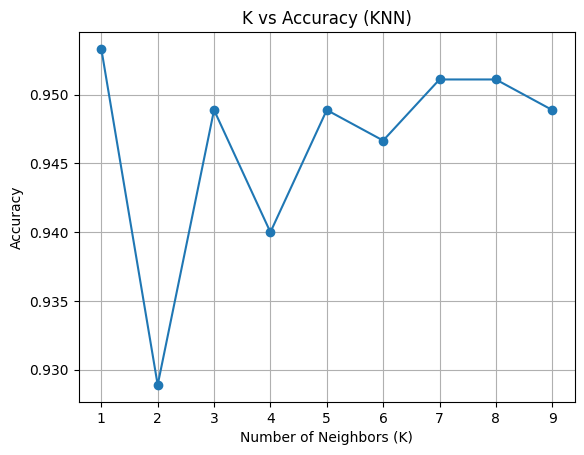

In [26]:
import matplotlib.pyplot as plt

k_values = []
accuracy_values = []

for k in range(1, 10):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    k_values.append(k)
    accuracy_values.append(acc)

# Plot Graph
plt.figure()
plt.plot(k_values, accuracy_values, marker='o')

plt.title("K vs Accuracy (KNN)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.grid()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
X=clean_data.iloc[:,:-1]
y=clean_data.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state=42)

In [31]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1050, 5)
Shape of X_test: (450, 5)
Shape of y_train: (1050,)
Shape of y_test: (450,)


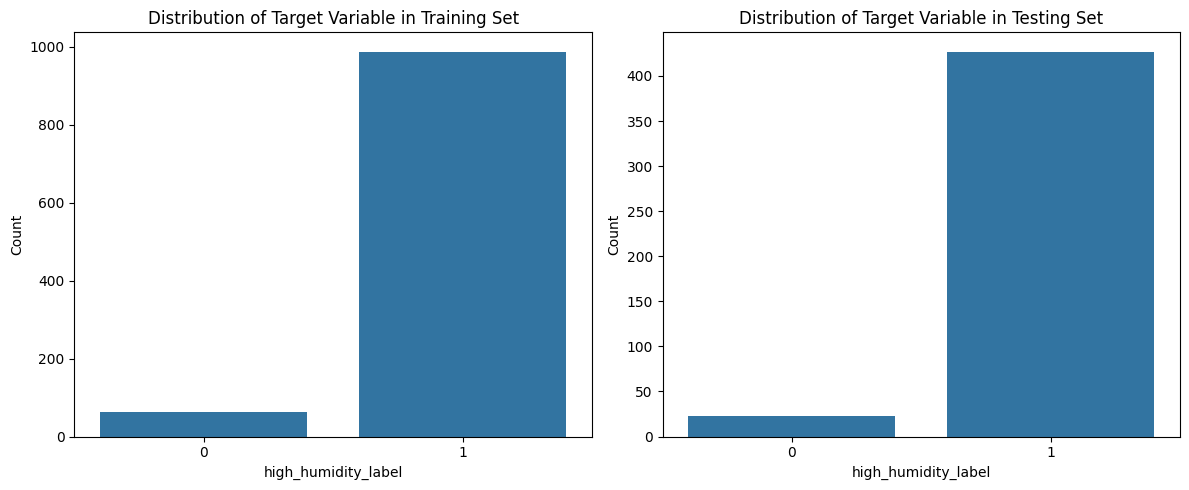

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Distribution of Target Variable in Training Set')
plt.xlabel('high_humidity_label')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_test)
plt.title('Distribution of Target Variable in Testing Set')
plt.xlabel('high_humidity_label')
plt.ylabel('Count')

plt.tight_layout()
plt.show()